# Tiny CNN with TensorBoard + Inline Visuals

This notebook trains the same tiny CNN as `tb_cnn_demo.py` on synthetic data and shows:
- Sample inputs
- Predictions vs. labels
- Loss curve
- TensorBoard logging (optional to view live)

Run all cells; adjust hyperparameters in the config cell.


In [ ]:
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter
import wandb

# Inline plots
%matplotlib inline



In [ ]:
# Config
epochs = 10
batch_size = 64
lr = 1e-3
num_samples = 1000
num_classes = 10
seed = 0
use_wandb = True
wandb_project = "tb-cnn-demo"

torch.manual_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

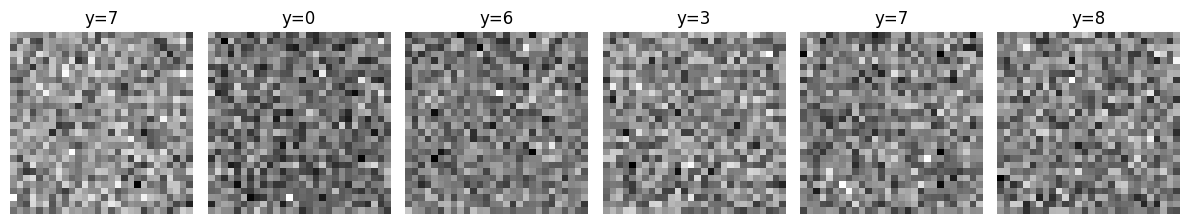

In [3]:
def make_synthetic_dataset(n=num_samples):
    x = torch.randn(n, 1, 28, 28)
    y = torch.randint(0, num_classes, (n,))
    return TensorDataset(x, y)

dataset = make_synthetic_dataset()
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Visualize a few examples
images, labels = next(iter(loader))
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for ax, img, label in zip(axes, images[:6], labels[:6]):
    ax.imshow(img[0], cmap="gray")
    ax.axis("off")
    ax.set_title(f"y={label.item()}")
plt.tight_layout()
plt.show()


In [4]:
class TinyCNN(nn.Module):
    def __init__(self, num_classes=num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)

model = TinyCNN().to(device)
model


TinyCNN(
  (net): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=784, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
logdir = Path("runs") / time.strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir=logdir)
logdir


PosixPath('runs/20251223-133349')

In [ ]:
loss_history = []

run = None
if use_wandb:
    run = wandb.init(
        project=wandb_project,
        config={
            "epochs": epochs,
            "batch_size": batch_size,
            "lr": lr,
            "device": device,
        },
    )
    wandb.watch(model, log_freq=100)

global_step = 0
for epoch in range(1, epochs + 1):
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        writer.add_scalar("loss/train_step", loss.item(), global_step)
        if run:
            wandb.log({"loss/train_step": loss.item(), "epoch": epoch}, step=global_step)
        global_step += 1

    avg_loss = running_loss / len(loader)
    loss_history.append(avg_loss)
    writer.add_scalar("loss/train_epoch", avg_loss, epoch)
    if run:
        wandb.log({"loss/train_epoch": avg_loss, "epoch": epoch}, step=global_step)
    print(f"Epoch {epoch}: loss={avg_loss:.4f}")

writer.add_text("meta", f"device={device}")
writer.close()
if run:
    print(f"W&B run URL: {run.url}")
    run.finish()
print(f"Logs written to {logdir}")


Epoch 1: loss=2.3128
Epoch 2: loss=2.3010
Epoch 3: loss=2.2916
Epoch 4: loss=2.2804
Epoch 5: loss=2.2644
Epoch 6: loss=2.2461
Epoch 7: loss=2.2162
Epoch 8: loss=2.1773
Epoch 9: loss=2.1221
Epoch 10: loss=2.0313
Logs written to runs/20251223-133349


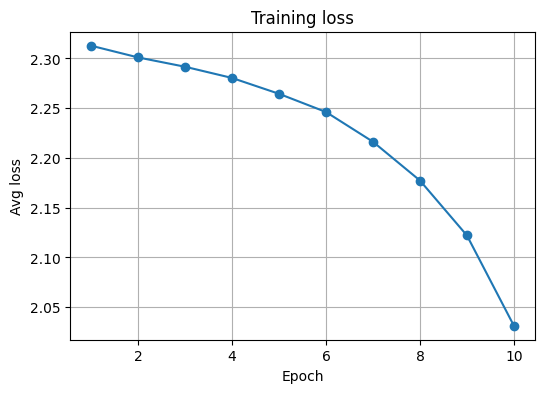

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Avg loss")
plt.title("Training loss")
plt.grid(True)
plt.show()


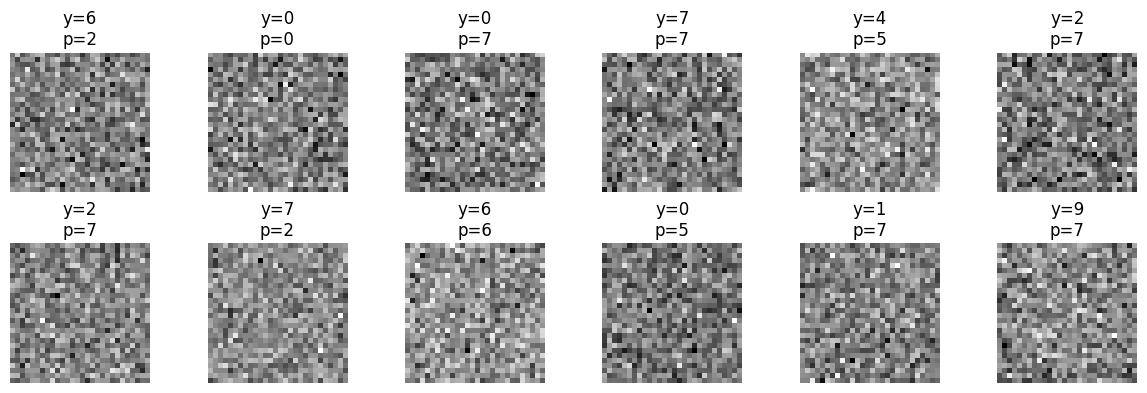

In [8]:
# Inspect predictions on a batch
images, labels = next(iter(loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    logits = model(images)
    preds = logits.argmax(dim=1)

images, labels, preds = images.cpu(), labels.cpu(), preds.cpu()
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, img, label, pred in zip(axes.flatten(), images[:12], labels[:12], preds[:12]):
    ax.imshow(img[0], cmap="gray")
    ax.axis("off")
    ax.set_title(f"y={label.item()}\np={pred.item()}")
plt.tight_layout()
plt.show()
